In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

Mandyoc uses total pressure to calculate solidus. Neglecting solidus depletion derivative term from Eq9, we have:

$T_s = T_{s0} + \frac{\partial T_s}{\partial P}|_X P$, adapting to depth derivative we have:

$T_s = T_{s0} + \frac{\partial T_s}{\partial z}|_X \frac{1}{\rho_0 g} P$

Assuming:

$\rho_0$ = 3300 kg/m $^3$

$g$ = 10 m/s $^2$

$T_{s0}$ = 1080 $^{\circ}$ C Dry Solidus temperature at surface (Lu and Huismans 2022)

$\frac{\partial T_s}{\partial z}|_X$ = 3.4 $\times 10^{-3}$ solidus depth derivative (Lu and Huismans 2022)



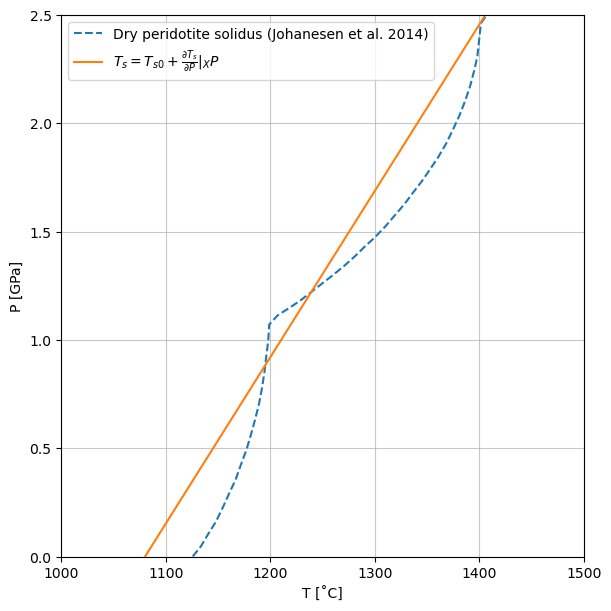

In [30]:
Johanesen_data = pd.read_excel(f"PTt_Data/Johanesen_Fig7_datasets.xlsx")

rho0 = 3300.0 #kg/m3
g = 10. #m/s2
Ts0 = 1080. #oC - Dry Solidus temperature at surface (Lu and Huismans 2022)
solidus_depth_derivative = 4.3e-3 #Km-1 (Lu and Huismans 2022)

P = np.arange(0, 2.6, 0.1) #GPa
Ts = Ts0 + solidus_depth_derivative*P*1.0e9*(1/(rho0*g))

fig, ax = plt.subplots(1, 1, figsize=(6,6), constrained_layout=True)

ax.plot(Johanesen_data.DryPeridotiteSolidusT, Johanesen_data.DryPeridotiteSolidusP/1000, '--', label='Dry peridotite solidus (Johanesen et al. 2014)') #GPa
ax.plot(Ts, P, '-', label=r"$T_s = T_{s0} + \frac{\partial T_s}{\partial P}|_X P$")

ax.set_xlabel(f"T [˚C]")
ax.set_ylabel(f"P [GPa]")

ax.set_xlim(1000, 1500)
ax.set_ylim(0, 2.5)

ax.legend(loc='upper left')
ax.grid('-k', alpha=0.7)

fig.savefig("solidus_comparison.png", dpi=200)